In [1]:
%pip install -q torch transformers datasets accelerate peft trl sentencepiece matplotlib tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Clone PRM800K dataset 
import os
if not os.path.exists("prm800k-main"):
    !wget -q https://github.com/openai/prm800k/archive/refs/heads/main.zip -O prm800k.zip
    !unzip -q prm800k.zip && rm prm800k.zip
    print("PRM800K dataset downloaded and extracted.")
else:
    print("PRM800K dataset already present.")

PRM800K dataset already present.


In [3]:
import json, os, random, re, warnings, glob as glob_mod
from collections import Counter
from pathlib import Path


os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

import matplotlib.pyplot as plt
import numpy as np
import torch
from datasets import Dataset
from peft import LoraConfig, get_peft_model, AutoPeftModelForCausalLM
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    DataCollatorForSeq2Seq,
)
from trl import SFTConfig, SFTTrainer
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

assert torch.backends.mps.is_available(), "MPS not available — this notebook requires Apple Silicon"
DEVICE = torch.device("mps")
print(f"PyTorch {torch.__version__}  |  Device: MPS (Apple Silicon)")

/opt/anaconda3/lib/python3.13/site-packages/bitsandbytes/cextension.py:34: UserWarning: The installed version of bitsandbytes was compiled without GPU support. 8-bit optimizers, 8-bit multiplication, and GPU quantization are unavailable.
  warn("The installed version of bitsandbytes was compiled without GPU support. "


'NoneType' object has no attribute 'cadam32bit_grad_fp32'
PyTorch 2.10.0  |  Device: MPS (Apple Silicon)


In [4]:
CONFIG = {
    # Paths 
    "data_root": "prm800k-main/prm800k/data",
    "output_dir": "qwen_prm_output",
    "model_name": "Qwen/Qwen2.5-1.5B-Instruct",

    # Debug mode
    "debug": False,
    "debug_train_size": 250,
    "debug_val_size": 50,

    # Data
    "use_phase1": True,
    "include_found_error": True,
    "max_seq_length": 384,
    "max_train_size": 2000,
    "max_val_size": 200,

    
    "lora_r": 8,
    "lora_alpha": 16,
    "lora_dropout": 0.05,
    "lora_target_modules": [
        "q_proj", "k_proj", "v_proj", "o_proj",
    ],

    # Training
    "num_train_epochs": 2,
    "per_device_train_batch_size": 2,
    "gradient_accumulation_steps": 2,  # effective batch size = 2 * 2 = 4
    "learning_rate": 2e-4,
    "lr_scheduler_type": "cosine",
    "warmup_ratio": 0.05,
    "gradient_checkpointing": True,
    "optim": "adamw_torch",
    "fp16": False,
    "bf16": False,
    "logging_steps": 10,
    "eval_steps": 250,
    "save_steps": 250,
    "save_total_limit": 3,
    "eval_strategy": "steps",
    "load_best_model_at_end": True,
    "metric_for_best_model": "eval_loss",

    # Label tokens
    "label_correct": "+",
    "label_neutral": "0",
    "label_incorrect": "-",

    # Resume
    "resume_from_checkpoint": None,  
}

# Debug
if CONFIG["debug"]:
    CONFIG["num_train_epochs"] = 1
    CONFIG["eval_steps"] = 50
    CONFIG["save_steps"] = 50
    CONFIG["logging_steps"] = 5
    print("DEBUG MODE: 1 epoch, limited data")
else:
    print(f"Full training: {CONFIG['num_train_epochs']} epochs")

Full training: 2 epochs


In [5]:
data_root = Path(CONFIG["data_root"])

print(f"{'File':<50} {'Size':>10}")
print("-" * 62)
for dirpath, _, filenames in os.walk(data_root):
    for f in sorted(filenames):
        fp = Path(dirpath) / f
        size = fp.stat().st_size
        if size > 1e6:
            size_str = f"{size / 1e6:.1f} MB"
        else:
            size_str = f"{size / 1e3:.1f} KB"
        print(f"{str(fp):<50} {size_str:>10}")

expected_files = ["phase2_train.jsonl", "phase2_test.jsonl"]
if CONFIG["use_phase1"]:
    expected_files.append("phase1_train.jsonl")

for fname in expected_files:
    fpath = data_root / fname
    assert fpath.exists(), f"Missing required file: {fpath}"
print(f"\nAll {len(expected_files)} required data files found.")

File                                                     Size
--------------------------------------------------------------
prm800k-main/prm800k/data/phase1_test.jsonl          829.1 KB
prm800k-main/prm800k/data/phase1_train.jsonl           7.9 MB
prm800k-main/prm800k/data/phase2_test.jsonl           12.2 MB
prm800k-main/prm800k/data/phase2_train.jsonl         456.1 MB

All 3 required data files found.


In [6]:
for fname in expected_files:
    fpath = data_root / fname
    records = []
    with open(fpath) as f:
        for i, line in enumerate(f):
            records.append(json.loads(line))
            if i >= 999:
                break

    print(f"\n{'=' * 60}")
    print(f"File: {fname}  ({len(records)} records sampled)")
    print(f"{'=' * 60}")

    
    rec = records[0]
    print(f"Top-level keys: {list(rec.keys())}")
    print(f"  question keys: {list(rec['question'].keys())}")
    print(f"  label keys:    {list(rec['label'].keys())}")
    print(f"  # steps:       {len(rec['label']['steps'])}")
    print(f"  finish_reason: {rec['label']['finish_reason']}")

    
    reasons = Counter(r["label"]["finish_reason"] for r in records)
    print(f"\n  finish_reason distribution (first {len(records)} records):")
    for reason, count in reasons.most_common():
        print(f"    {reason:<20} {count:>5}  ({100*count/len(records):.1f}%)")

    # Count total records in file
    with open(fpath) as f:
        total = sum(1 for _ in f)
    print(f"\n  Total records in file: {total:,}")


File: phase2_train.jsonl  (1000 records sampled)
Top-level keys: ['labeler', 'timestamp', 'generation', 'is_quality_control_question', 'is_initial_screening_question', 'question', 'label']
  question keys: ['problem', 'ground_truth_solution', 'ground_truth_answer', 'pre_generated_steps', 'pre_generated_answer', 'pre_generated_verifier_score']
  label keys:    ['steps', 'total_time', 'finish_reason']
  # steps:       13
  finish_reason: found_error

  finish_reason distribution (first 1000 records):
    found_error            545  (54.5%)
    solution               428  (42.8%)
    give_up                 24  (2.4%)
    bad_problem              3  (0.3%)

  Total records in file: 97,782

File: phase2_test.jsonl  (1000 records sampled)
Top-level keys: ['labeler', 'timestamp', 'generation', 'is_quality_control_question', 'is_initial_screening_question', 'question', 'label']
  question keys: ['problem', 'ground_truth_solution', 'ground_truth_answer', 'pre_generated_steps', 'pre_generated_

In [7]:
def load_jsonl(filepath):
    records = []
    with open(filepath) as f:
        for line in f:
            records.append(json.loads(line))
    return records

In [8]:
RATING_MAP = {1: "+", 0: "0", -1: "-", None: "0"}

def extract_trajectory(record):
    
    question = record["question"]
    label = record["label"]
    steps_data = label["steps"]

    steps = []
    skip_record = False

    for step in steps_data:
        chosen = step.get("chosen_completion")
        human = step.get("human_completion")
        completions = step.get("completions", [])

        if chosen is not None:

            comp = completions[chosen]
            text = comp["text"]
            rating = comp.get("rating")
        elif human is not None:
        
            text = human if isinstance(human, str) else human.get("text", "")
            rating = 1
        elif len(completions) > 0:

            comp = completions[0]
            text = comp["text"]
            rating = comp.get("rating")
        else:
            
            skip_record = True
            break

        label_str = RATING_MAP.get(rating, "0")
        steps.append({"text": text.strip(), "rating": label_str})

    if skip_record or len(steps) == 0:
        return None

    return {
        "problem": question["problem"],
        "ground_truth_answer": question.get("ground_truth_answer", ""),
        "steps": steps,
        "finish_reason": label["finish_reason"],
        "is_complete": label["finish_reason"] == "solution",
    }

In [9]:
SYSTEM_PROMPT = (
    "You are a math solution verifier. Given a math problem and a step-by-step "
    "solution, evaluate each step as correct (+), neutral (0), or incorrect (-)."
)

def format_as_chat(trajectory):
    steps = trajectory["steps"]

    user_lines = [f"**Problem:** {trajectory['problem']}", "", "**Solution to verify:**"]
    for i, step in enumerate(steps, 1):
        user_lines.append(f"Step {i}: {step['text']}")

    assistant_lines = []
    for i, step in enumerate(steps, 1):
        assistant_lines.append(f"Step {i}: {step['rating']}")

    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": "\n".join(user_lines)},
        {"role": "assistant", "content": "\n".join(assistant_lines)},
    ]


def parse_verdicts(text):
    
    word_map = {"correct": "+", "neutral": "0", "incorrect": "-"}
    verdicts = []

    for line in text.strip().split("\n"):
        
        line = re.sub(r'^[\s\-\u2013\u2014*\u2022]+', '', line).strip()
        if not line.lower().startswith("step"):
            continue
        parts = line.split(":", 1)
        if len(parts) != 2:
            continue
        value = parts[1].strip()
        value_lower = value.lower().strip("* ")

        
        if value_lower in ("+", "0", "-"):
            verdicts.append(value_lower)
            continue

   
        matched = False
        for word, symbol in word_map.items():
            if word in value_lower:
                verdicts.append(symbol)
                matched = True
                break
        if not matched:
            
            paren = re.search(r'\([+\-\u2013\u20140]\)', value)
            if paren:
                sym = paren.group(0)[1]
                if sym in ('\u2013', '\u2014'):
                    sym = '-'
                verdicts.append(sym)

    return verdicts

In [10]:
# Load all data files
ALLOWED_REASONS = {"solution", "found_error"} if CONFIG["include_found_error"] else {"solution"}

def process_file(filepath, allowed_reasons):

    raw = load_jsonl(filepath)
    trajectories = []
    skipped = Counter()
    for rec in raw:
        reason = rec["label"]["finish_reason"]
        if reason not in allowed_reasons:
            skipped[reason] += 1
            continue
        traj = extract_trajectory(rec)
        if traj is None:
            skipped["no_steps"] += 1
            continue
        trajectories.append(traj)
    return trajectories, skipped

# Process training data
train_trajectories = []
print("Loading training data...")
for fname in ["phase2_train.jsonl"] + (["phase1_train.jsonl"] if CONFIG["use_phase1"] else []):
    trajs, skipped = process_file(data_root / fname, ALLOWED_REASONS)
    print(f"  {fname}: {len(trajs):,} trajectories kept, skipped: {dict(skipped)}")
    train_trajectories.extend(trajs)

# Process validation data
print("\nLoading validation data...")
val_trajectories, val_skipped = process_file(data_root / "phase2_test.jsonl", ALLOWED_REASONS)
print(f"  phase2_test.jsonl: {len(val_trajectories):,} trajectories kept, skipped: {dict(val_skipped)}")

# Apply data size limits
random.shuffle(train_trajectories)
random.shuffle(val_trajectories)

if CONFIG["debug"]:
    max_train = CONFIG["debug_train_size"]
    max_val = CONFIG["debug_val_size"]
    print(f"\nDebug mode: using {max_train} train, {max_val} val")
else:
    max_train = CONFIG["max_train_size"]
    max_val = CONFIG["max_val_size"]
    print(f"\nFull mode: capping at {max_train:,} train, {max_val:,} val")

train_trajectories = train_trajectories[:max_train]
val_trajectories = val_trajectories[:max_val]

# Format as chat messages
train_chats = [format_as_chat(t) for t in train_trajectories]
val_chats = [format_as_chat(t) for t in val_trajectories]

# Stats
all_ratings = [s["rating"] for t in train_trajectories for s in t["steps"]]
rating_dist = Counter(all_ratings)
print(f"\nTraining set: {len(train_chats):,} examples")
print(f"Validation set: {len(val_chats):,} examples")
print(f"\nStep-level rating distribution (train):")
for label in ["+", "0", "-"]:
    count = rating_dist.get(label, 0)
    print(f"  {label}: {count:>7,}  ({100*count/sum(rating_dist.values()):.1f}%)")

# Show 3 examples
print("\n" + "=" * 60)
print("Example formatted conversations:")
print("=" * 60)
for i, (traj, chat) in enumerate(zip(train_trajectories[:3], train_chats[:3])):
    print(f"\n--- Example {i+1} (finish_reason={traj['finish_reason']}, {len(traj['steps'])} steps) ---")
    print(f"[SYSTEM] {chat[0]['content'][:80]}...")
    print(f"[USER]   {chat[1]['content'][:200]}...")
    print(f"[ASST]   {chat[2]['content']}")

Loading training data...
  phase2_train.jsonl: 93,668 trajectories kept, skipped: {'give_up': 3839, 'bad_problem': 275}
  phase1_train.jsonl: 808 trajectories kept, skipped: {'give_up': 141}

Loading validation data...
  phase2_test.jsonl: 2,664 trajectories kept, skipped: {'give_up': 98}

Full mode: capping at 2,000 train, 200 val

Training set: 2,000 examples
Validation set: 200 examples

Step-level rating distribution (train):
  +:  11,598  (80.4%)
  0:   1,099  (7.6%)
  -:   1,735  (12.0%)

Example formatted conversations:

--- Example 1 (finish_reason=found_error, 7 steps) ---
[SYSTEM] You are a math solution verifier. Given a math problem and a step-by-step soluti...
[USER]   **Problem:** Po is trying to solve the following equation by completing the square: $$49x^2+56x-64 = 0.$$He successfully rewrites the above equation in the following form: $$(ax + b)^2 = c,$$where $a$...
[ASST]   Step 1: 0
Step 2: 0
Step 3: +
Step 4: +
Step 5: +
Step 6: +
Step 7: -

--- Example 2 (finish_rea

In [11]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"], trust_remote_code=True)

# Set pad token if missing
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

print(f"Tokenizer: {CONFIG['model_name']}")
print(f"Vocab size: {tokenizer.vocab_size:,}")
print(f"Pad token: '{tokenizer.pad_token}' (id={tokenizer.pad_token_id})")
print(f"EOS token: '{tokenizer.eos_token}' (id={tokenizer.eos_token_id})")

# Verify label tokens
print("\nLabel token verification:")
for label_name, label_char in [("correct", "+"), ("neutral", "0"), ("incorrect", "-")]:
    token_ids = tokenizer.encode(label_char, add_special_tokens=False)
    print(f"  '{label_char}' -> token_ids={token_ids}, "
          f"decoded='{tokenizer.decode(token_ids)}', "
          f"single_token={'yes' if len(token_ids) == 1 else 'WARNING: multi-token!'}")

Tokenizer: Qwen/Qwen2.5-1.5B-Instruct
Vocab size: 151,643
Pad token: '<|endoftext|>' (id=151643)
EOS token: '<|im_end|>' (id=151645)

Label token verification:
  '+' -> token_ids=[10], decoded='+', single_token=yes
  '0' -> token_ids=[15], decoded='0', single_token=yes
  '-' -> token_ids=[12], decoded='-', single_token=yes


Tokenizing all examples...


Tokenizing:   0%|          | 0/2200 [00:00<?, ?it/s]


Token length statistics (all examples):
  Min:  99
  Mean: 414
  Max:  1434
  P95:  863
  P99:  1148

  Truncated (>384 tokens): 994 (45.2%)


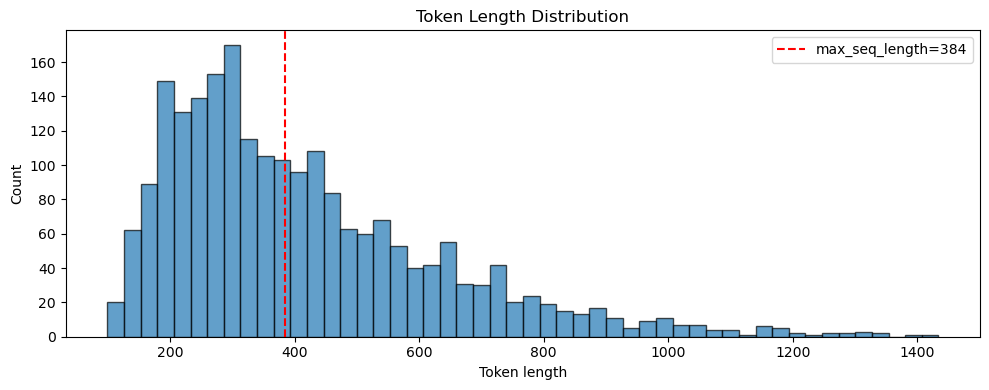


Pre-tokenizing with label masking...


Train:   0%|          | 0/2000 [00:00<?, ?it/s]

Val:   0%|          | 0/200 [00:00<?, ?it/s]


Train: 1217 kept, 783 skipped (prompt > max_seq_length)
Val:   133 kept, 67 skipped
Datasets created: train=1217, val=133

Sample verification:
  Total tokens: 344
  Prompt tokens (masked): 303
  Completion tokens (loss computed): 41
  Completion text: Step 1: +
Step 2: +
Step 3: 0
Step 4: +
Step 5: 0
Step 6: +
Step 7: +<|im_end|>



In [12]:
def get_token_ids(result):

    if hasattr(result, "keys"):
        ids = result["input_ids"]
        if isinstance(ids, list) and len(ids) > 0 and isinstance(ids[0], list):
            return ids[0]
        return ids
    if isinstance(result, list):
        return result
    return list(result)

# Token length analysis
print("Tokenizing all examples...")
all_lengths = []
for chat in tqdm(train_chats + val_chats, desc="Tokenizing"):
    token_ids = get_token_ids(tokenizer.apply_chat_template(chat, tokenize=True))
    all_lengths.append(len(token_ids))

all_lengths = np.array(all_lengths)
print(f"\nToken length statistics (all examples):")
print(f"  Min:  {all_lengths.min()}")
print(f"  Mean: {all_lengths.mean():.0f}")
print(f"  Max:  {all_lengths.max()}")
print(f"  P95:  {np.percentile(all_lengths, 95):.0f}")
print(f"  P99:  {np.percentile(all_lengths, 99):.0f}")

n_truncated = (all_lengths > CONFIG["max_seq_length"]).sum()
print(f"\n  Truncated (>{CONFIG['max_seq_length']} tokens): {n_truncated} "
      f"({100*n_truncated/len(all_lengths):.1f}%)")

# Histogram
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.hist(all_lengths, bins=50, edgecolor="black", alpha=0.7)
ax.axvline(CONFIG["max_seq_length"], color="red", linestyle="--",
           label=f"max_seq_length={CONFIG['max_seq_length']}")
ax.set_xlabel("Token length")
ax.set_ylabel("Count")
ax.set_title("Token Length Distribution")
ax.legend()
plt.tight_layout()
plt.show()

# Pre-tokenize with label masking
def tokenize_with_labels(messages):
    """Tokenize chat messages and mask prompt tokens in labels."""
    max_len = CONFIG["max_seq_length"]

    full_ids = list(get_token_ids(tokenizer.apply_chat_template(messages, tokenize=True)))
    prompt_ids = get_token_ids(tokenizer.apply_chat_template(
        messages[:2], tokenize=True, add_generation_prompt=True
    ))
    prompt_len = len(prompt_ids)

    if prompt_len >= max_len:
        return None

    full_ids = full_ids[:max_len]
    labels = [-100] * prompt_len + full_ids[prompt_len:]
    labels = labels[:len(full_ids)]
    attention_mask = [1] * len(full_ids)

    return {"input_ids": full_ids, "attention_mask": attention_mask, "labels": labels}

print("\nPre-tokenizing with label masking...")
train_tokenized = []
train_skipped = 0
for c in tqdm(train_chats, desc="Train"):
    result = tokenize_with_labels(c)
    if result is not None:
        train_tokenized.append(result)
    else:
        train_skipped += 1

val_tokenized = []
val_skipped = 0
for c in tqdm(val_chats, desc="Val"):
    result = tokenize_with_labels(c)
    if result is not None:
        val_tokenized.append(result)
    else:
        val_skipped += 1

print(f"\nTrain: {len(train_tokenized)} kept, {train_skipped} skipped (prompt > max_seq_length)")
print(f"Val:   {len(val_tokenized)} kept, {val_skipped} skipped")

train_dataset = Dataset.from_dict({
    "input_ids": [t["input_ids"] for t in train_tokenized],
    "attention_mask": [t["attention_mask"] for t in train_tokenized],
    "labels": [t["labels"] for t in train_tokenized],
})
val_dataset = Dataset.from_dict({
    "input_ids": [t["input_ids"] for t in val_tokenized],
    "attention_mask": [t["attention_mask"] for t in val_tokenized],
    "labels": [t["labels"] for t in val_tokenized],
})
print(f"Datasets created: train={len(train_dataset)}, val={len(val_dataset)}")

# Verify label masking
sample = train_tokenized[0]
n_masked = sum(1 for l in sample["labels"] if l == -100)
n_real = sum(1 for l in sample["labels"] if l != -100)
print(f"\nSample verification:")
print(f"  Total tokens: {len(sample['input_ids'])}")
print(f"  Prompt tokens (masked): {n_masked}")
print(f"  Completion tokens (loss computed): {n_real}")
assert n_real > 0, "ERROR: No completion tokens found — labels are all -100!"
completion_text = tokenizer.decode([l for l in sample["labels"] if l != -100])
print(f"  Completion text: {completion_text[:200]}")

In [13]:
model = AutoModelForCausalLM.from_pretrained(
    CONFIG["model_name"],
    torch_dtype=torch.float32,
    device_map=None,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)
model = model.to(DEVICE)

print(f"Model device: {next(model.parameters()).device}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B")

# Enable input gradients for LoRA
model.enable_input_require_grads()

# Enable gradient checkpointing for memory efficiency
if CONFIG["gradient_checkpointing"]:
    model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Model device: mps:0
Parameters: 1.54B


In [14]:
# Evaluation function
def evaluate_predictions(model, tokenizer, val_trajectories, val_chats, n_samples=None, label=""):

    model.eval()

    if n_samples is None:
        n_samples = len(val_chats)
    n_samples = min(n_samples, len(val_chats))

    all_true, all_pred, results = [], [], []
    n_parse_failures = 0

    for i in tqdm(range(n_samples), desc=f"Evaluating {label}"):
        traj = val_trajectories[i]
        chat = val_chats[i]

        input_messages = [chat[0], chat[1]]
        input_text = tokenizer.apply_chat_template(
            input_messages, tokenize=False, add_generation_prompt=True
        )
        inputs = tokenizer(input_text, return_tensors="pt").to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs, max_new_tokens=128, do_sample=False,
                temperature=1.0, pad_token_id=tokenizer.pad_token_id,
            )
        new_tokens = outputs[0][inputs["input_ids"].shape[1]:]
        pred_text = tokenizer.decode(new_tokens, skip_special_tokens=True)

        true_labels = [s["rating"] for s in traj["steps"]]
        pred_labels = parse_verdicts(pred_text)

        if len(pred_labels) == 0:
            n_parse_failures += 1

        results.append({
            "problem": traj["problem"][:100],
            "n_steps": len(traj["steps"]),
            "true_labels": true_labels,
            "pred_labels": pred_labels,
            "pred_text": pred_text,
        })

        min_len = min(len(true_labels), len(pred_labels))
        all_true.extend(true_labels[:min_len])
        all_pred.extend(pred_labels[:min_len])

    # Results
    parse_rate = (n_samples - n_parse_failures) / n_samples if n_samples > 0 else 0
    metrics = {"parse_rate": parse_rate}

    print(f"\n{'=' * 55}")
    print(f"  {label}")
    print(f"{'=' * 55}")
    print(f"  Format compliance: {n_samples - n_parse_failures}/{n_samples} ({parse_rate:.1%})")

    if n_parse_failures > 0 and n_parse_failures == n_samples:
        print(f"\n  Sample raw outputs (first 3 unparseable):")
        for res in results[:3]:
            if len(res["pred_labels"]) == 0:
                print(f"    [{res['problem'][:50]}...]")
                print(f"      → {res['pred_text'][:150]}")

    if all_true:
        correct = sum(t == p for t, p in zip(all_true, all_pred))
        total = len(all_true)
        accuracy = correct / total
        metrics.update({"accuracy": accuracy, "correct": correct, "total": total})

        print(f"\n  >>> Overall Accuracy: {accuracy:.4f} ({correct}/{total} steps) <<<\n")

        for lbl in ["+", "0", "-"]:
            mask = [t == lbl for t in all_true]
            if sum(mask) == 0:
                continue
            cc = sum(p == lbl for t, p, m in zip(all_true, all_pred, mask) if m)
            ct = sum(mask)
            metrics[f"acc_{lbl}"] = cc / ct
            print(f"  Accuracy on '{lbl}': {cc}/{ct} = {cc/ct:.4f}")

        true_errors = sum(1 for t in all_true if t == "-")
        detected = sum(1 for t, p in zip(all_true, all_pred) if t == "-" and p == "-")
        if true_errors > 0:
            metrics["error_recall"] = detected / true_errors
            print(f"  Error recall  '-': {detected}/{true_errors} = {detected/true_errors:.4f}")

        # Confusion matrix
        labels = ["+", "0", "-"]
        print(f"\n  Confusion Matrix (rows=true, cols=predicted):")
        print(f"  {'':>8} {'pred +':>8} {'pred 0':>8} {'pred -':>8}")
        for tl in labels:
            row = [sum(1 for t, p in zip(all_true, all_pred) if t == tl and p == pl) for pl in labels]
            print(f"  true {tl:>2}: {row[0]:>8} {row[1]:>8} {row[2]:>8}")
    else:
        print(f"\n  No parseable predictions — accuracy cannot be computed.")

    return results, metrics

# Run baseline evaluation
n_eval = 50
print(f"Running baseline evaluation on {n_eval} validation examples...\n")
baseline_results, baseline_metrics = evaluate_predictions(
    model, tokenizer, val_trajectories, val_chats,
    n_samples=n_eval, label="Base Model (before fine-tuning)"
)
print(f"\nBaseline accuracy: {baseline_metrics.get('accuracy', 'N/A (unparseable)')}")

Running baseline evaluation on 50 validation examples...



Evaluating Base Model (before fine-tuning):   0%|          | 0/50 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



  Base Model (before fine-tuning)
  Format compliance: 14/50 (28.0%)

  >>> Overall Accuracy: 0.6410 (50/78 steps) <<<

  Accuracy on '+': 49/63 = 0.7778
  Accuracy on '0': 1/10 = 0.1000
  Accuracy on '-': 0/5 = 0.0000
  Error recall  '-': 0/5 = 0.0000

  Confusion Matrix (rows=true, cols=predicted):
             pred +   pred 0   pred -
  true  +:       49       14        0
  true  0:        9        1        0
  true  -:        3        2        0

Baseline accuracy: 0.6410256410256411


In [15]:
# Apply LoRA adapters
lora_config = LoraConfig(
    r=CONFIG["lora_r"],
    lora_alpha=CONFIG["lora_alpha"],
    lora_dropout=CONFIG["lora_dropout"],
    target_modules=CONFIG["lora_target_modules"],
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1409587513492263


In [16]:
# SFT Training
output_dir = CONFIG["output_dir"]
os.makedirs(output_dir, exist_ok=True)


collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    padding=True,
    return_tensors="pt",
)

sft_config = SFTConfig(
    output_dir=output_dir,
    num_train_epochs=CONFIG["num_train_epochs"],
    per_device_train_batch_size=CONFIG["per_device_train_batch_size"],
    per_device_eval_batch_size=CONFIG["per_device_train_batch_size"],
    gradient_accumulation_steps=CONFIG["gradient_accumulation_steps"],
    learning_rate=CONFIG["learning_rate"],
    lr_scheduler_type=CONFIG["lr_scheduler_type"],
    warmup_ratio=CONFIG["warmup_ratio"],
    optim=CONFIG["optim"],
    bf16=CONFIG["bf16"],
    fp16=CONFIG["fp16"],
    gradient_checkpointing=CONFIG["gradient_checkpointing"],
    gradient_checkpointing_kwargs={"use_reentrant": False},
    logging_steps=CONFIG["logging_steps"],
    eval_strategy=CONFIG["eval_strategy"],
    eval_steps=CONFIG["eval_steps"],
    save_steps=CONFIG["save_steps"],
    save_total_limit=CONFIG["save_total_limit"],
    load_best_model_at_end=CONFIG["load_best_model_at_end"],
    metric_for_best_model=CONFIG["metric_for_best_model"],
    remove_unused_columns=False,
    report_to="none",
    seed=SEED,
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=collator,
    processing_class=tokenizer,
)

# Check for existing checkpoints to resume from
resume_ckpt = CONFIG["resume_from_checkpoint"]
if resume_ckpt is None:
    ckpts = sorted(glob_mod.glob(os.path.join(output_dir, "checkpoint-*")))
    if ckpts:
        resume_ckpt = ckpts[-1]
        print(f"Found existing checkpoint, resuming from: {resume_ckpt}")

print(f"Starting training... (resume_from_checkpoint={resume_ckpt})")
trainer.train(resume_from_checkpoint=resume_ckpt)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Truncating train dataset:   0%|          | 0/1217 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/133 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Found existing checkpoint, resuming from: qwen_prm_output/checkpoint-610
Starting training... (resume_from_checkpoint=qwen_prm_output/checkpoint-610)


Step,Training Loss,Validation Loss


TrainOutput(global_step=610, training_loss=0.0, metrics={'train_runtime': 0.0015, 'train_samples_per_second': 1628219.448, 'train_steps_per_second': 408058.284, 'total_flos': 6026237232768000.0, 'train_loss': 0.0})

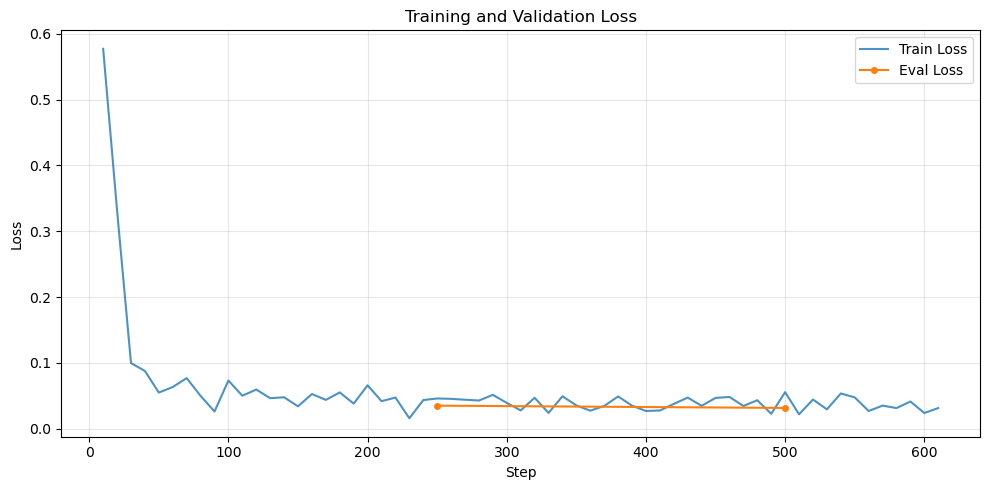

Best eval loss: 0.0315 at step 500


In [17]:
# Plot training curves
log_history = trainer.state.log_history

train_steps = [x["step"] for x in log_history if "loss" in x]
train_loss = [x["loss"] for x in log_history if "loss" in x]
eval_steps_log = [x["step"] for x in log_history if "eval_loss" in x]
eval_loss = [x["eval_loss"] for x in log_history if "eval_loss" in x]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(train_steps, train_loss, label="Train Loss", alpha=0.8)
if eval_loss:
    ax.plot(eval_steps_log, eval_loss, label="Eval Loss", marker="o", markersize=4)
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Training and Validation Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

if eval_loss:
    print(f"Best eval loss: {min(eval_loss):.4f} at step {eval_steps_log[eval_loss.index(min(eval_loss))]}")

In [18]:
# Step-level evaluation on fine-tuned model
n_eval = 50
finetuned_results, finetuned_metrics = evaluate_predictions(
    model, tokenizer, val_trajectories, val_chats,
    n_samples=n_eval, label="Fine-Tuned Model"
)

# Comparison Base vs Fine-Tuned 
print(f"\n{'=' * 60}")
print(f"  COMPARISON: Base Model vs Fine-Tuned Model")
print(f"{'=' * 60}")
print(f"{'Metric':<30} {'Base':>12} {'Fine-Tuned':>12}")
print(f"{'-' * 60}")

for key, name in [
    ("parse_rate", "Format Compliance"),
    ("accuracy", "Overall Accuracy"),
    ("acc_+", "Accuracy on '+'"),
    ("acc_0", "Accuracy on '0'"),
    ("acc_-", "Accuracy on '-'"),
    ("error_recall", "Error Recall ('-')"),
]:
    base_val = baseline_metrics.get(key)
    ft_val = finetuned_metrics.get(key)
    base_str = f"{base_val:.4f}" if base_val is not None else "N/A"
    ft_str = f"{ft_val:.4f}" if ft_val is not None else "N/A"
    delta = ""
    if base_val is not None and ft_val is not None:
        diff = ft_val - base_val
        delta = f"  ({'+' if diff >= 0 else ''}{diff:.4f})"
    print(f"{name:<30} {base_str:>12} {ft_str:>12}{delta}")

Evaluating Fine-Tuned Model:   0%|          | 0/50 [00:00<?, ?it/s]


  Fine-Tuned Model
  Format compliance: 50/50 (100.0%)

  >>> Overall Accuracy: 0.9467 (320/338 steps) <<<

  Accuracy on '+': 281/282 = 0.9965
  Accuracy on '0': 0/16 = 0.0000
  Accuracy on '-': 39/40 = 0.9750
  Error recall  '-': 39/40 = 0.9750

  Confusion Matrix (rows=true, cols=predicted):
             pred +   pred 0   pred -
  true  +:      281        1        0
  true  0:       16        0        0
  true  -:        1        0       39

  COMPARISON: Base Model vs Fine-Tuned Model
Metric                                 Base   Fine-Tuned
------------------------------------------------------------
Format Compliance                    0.2800       1.0000  (+0.7200)
Overall Accuracy                     0.6410       0.9467  (+0.3057)
Accuracy on '+'                      0.7778       0.9965  (+0.2187)
Accuracy on '0'                      0.1000       0.0000  (-0.1000)
Accuracy on '-'                      0.0000       0.9750  (+0.9750)
Error Recall ('-')                   0.0000    

In [19]:
# Side by side examples
print("Side-by-side comparison (first 5 examples):\n")
for i, res in enumerate(finetuned_results[:5]):
    print(f"{'─' * 60}")
    print(f"Example {i+1}: {res['problem']}...")
    print(f"  Steps: {res['n_steps']}")
    print(f"  True labels: {' '.join(res['true_labels'])}")
    pred_str = ' '.join(res['pred_labels']) if res['pred_labels'] else '(parse failed)'
    print(f"  Pred labels: {pred_str}")
    match = sum(t == p for t, p in zip(res['true_labels'], res['pred_labels']))
    total = min(len(res['true_labels']), len(res['pred_labels']))
    if total > 0:
        print(f"  Match: {match}/{total}")
    else:
        print(f"  Raw prediction: {res['pred_text'][:150]}")
print(f"{'─' * 60}")

Side-by-side comparison (first 5 examples):

────────────────────────────────────────────────────────────
Example 1: What is the probability that a randomly selected integer in the set $$\{1,2,3,\ldots,100\}$$  is div...
  Steps: 5
  True labels: + + + + -
  Pred labels: + + + + -
  Match: 5/5
────────────────────────────────────────────────────────────
Example 2: The set of points $(x,y,z)$ that satisfy
\[2x = 3y = -z\]is a line.

The set of points $(x,y,z)$ tha...
  Steps: 2
  True labels: + -
  Pred labels: + -
  Match: 2/2
────────────────────────────────────────────────────────────
Example 3: Find the unique $\textbf{odd}$ integer $t$ such that $0<t<23$ and $t+2$ is the inverse of $t$ modulo...
  Steps: 9
  True labels: + + + + + + + + -
  Pred labels: + + + + + + + + -
  Match: 9/9
────────────────────────────────────────────────────────────
Example 4: What is the result when the greatest common factor of 6432 and 132 is increased by 11?...
  Steps: 4
  True labels: + + + -
  Pre

In [20]:
def verify_solution(problem, steps, model, tokenizer):

    model.eval()

    # Build user message
    user_lines = [f"**Problem:** {problem}", "", "**Solution to verify:**"]
    for i, step in enumerate(steps, 1):
        user_lines.append(f"Step {i}: {step}")

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": "\n".join(user_lines)},
    ]

    input_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=128,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
        )

    new_tokens = outputs[0][inputs["input_ids"].shape[1] :]
    raw_output = tokenizer.decode(new_tokens, skip_special_tokens=True)
    verdicts = parse_verdicts(raw_output)

    return {"verdicts": verdicts, "raw_output": raw_output}

In [21]:
# Demo run verifier on 3 examples


correct_trajs = [t for t in val_trajectories if t["finish_reason"] == "solution"]
if correct_trajs:
    t = correct_trajs[0]
    print("=" * 60)
    print("DEMO 1: Correct solution from test set")
    print(f"Problem: {t['problem'][:200]}")
    print(f"Ground truth labels: {[s['rating'] for s in t['steps']]}")
    result = verify_solution(t["problem"], [s["text"] for s in t["steps"]], model, tokenizer)
    print(f"Predicted labels:    {result['verdicts']}")
    print(f"Raw output: {result['raw_output']}")


error_trajs = [t for t in val_trajectories if t["finish_reason"] == "found_error"]
if error_trajs:
    t = error_trajs[0]
    print("\n" + "=" * 60)
    print("DEMO 2: Solution with error from test set")
    print(f"Problem: {t['problem'][:200]}")
    print(f"Ground truth labels: {[s['rating'] for s in t['steps']]}")
    result = verify_solution(t["problem"], [s["text"] for s in t["steps"]], model, tokenizer)
    print(f"Predicted labels:    {result['verdicts']}")
    print(f"Raw output: {result['raw_output']}")


print("\n" + "=" * 60)
print("DEMO 3: Manually constructed incorrect solution")
demo_problem = "What is the value of 2 + 3 * 4?"
demo_steps = [
    "We need to compute 2 + 3 * 4.",
    "First, add 2 + 3 = 5.",
    "Then multiply 5 * 4 = 20.",
    "So the answer is 20.",
]
print(f"Problem: {demo_problem}")
print(f"Steps: {demo_steps}")
print("(Step 2 is wrong — should do multiplication first: 3*4=12, then 2+12=14)")
result = verify_solution(demo_problem, demo_steps, model, tokenizer)
print(f"Predicted labels: {result['verdicts']}")
print(f"Raw output: {result['raw_output']}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


DEMO 1: Correct solution from test set
Problem: Simplify $(-k + 4) + (-2 + 3k)$.
Ground truth labels: ['+', '+', '+', '+', '+']
Predicted labels:    ['+', '+', '+', '+', '+']
Raw output: Step 1: +
Step 2: +
Step 3: +
Step 4: +
Step 5: +

DEMO 2: Solution with error from test set
Problem: What is the probability that a randomly selected integer in the set $$\{1,2,3,\ldots,100\}$$  is divisible by 2 and not divisible by 3? Express your answer as a common fraction.
Ground truth labels: ['+', '+', '+', '+', '-']
Predicted labels:    ['+', '+', '+', '+', '-']
Raw output: Step 1: +
Step 2: +
Step 3: +
Step 4: +
Step 5: -

DEMO 3: Manually constructed incorrect solution
Problem: What is the value of 2 + 3 * 4?
Steps: ['We need to compute 2 + 3 * 4.', 'First, add 2 + 3 = 5.', 'Then multiply 5 * 4 = 20.', 'So the answer is 20.']
(Step 2 is wrong — should do multiplication first: 3*4=12, then 2+12=14)
Predicted labels: ['+', '+', '+', '-']
Raw output: Step 1: +
Step 2: +
Step 3: +
Step 4: -
